## 简单实现

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)


In [ ]:
def synthetic_data(w, b, num_examples):
    # 生成 y=Xw+b+噪声
    X = np.random.normal(0, 1, (num_examples, len(w)))
    y = np.dot(X, w) + b
    y += np.random.normal(0, 0.01, y.shape)
    # y.reshape((-1, 1)) 把 y 变成一个 N 行 1 列的二维数组。原来 y 是一维的# (1000,)，之后变成：# (1000, 1)
    # -1 表示：这一维让 numpy 自动推断。
    return X, y.reshape((-1, 1))


true_w = np.array([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print(features[0], labels[0])


[1.76405235 0.40015721] [6.35224097]


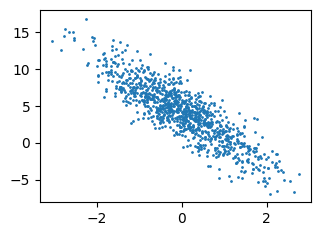

In [3]:
plt.figure(figsize=(3.5, 2.5))
plt.scatter(features[:, 1], labels, 1)
plt.show()


In [4]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = indices[i:min(i + batch_size, num_examples)]
        yield features[batch_indices], labels[batch_indices]


In [5]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, y)
    break

[[-0.36111313  0.60896234]
 [-0.6436184  -2.22340315]
 [ 0.5383296  -0.14244542]
 [ 0.192729    0.69643867]
 [-0.44092263 -0.2803555 ]
 [-1.36516288  1.94709864]
 [-0.11816405 -0.6801782 ]
 [ 1.26507784  0.21149701]
 [ 2.69622405 -0.07392467]
 [-0.47003288 -0.21673147]] [[ 1.42245059]
 [10.47021953]
 [ 5.77109531]
 [ 2.21581827]
 [ 4.27512269]
 [-5.17331613]
 [ 6.2780246 ]
 [ 5.99301332]
 [ 9.84866134]
 [ 3.98319183]]


上边已经准备好了实验数据

下边开始准备训练

In [6]:
w = np.random.normal(0, 0.01, size=(2, 1))
b = np.zeros(1)


In [7]:
def linreg(X, w, b):
    # 线性回归模型
    return np.dot(X, w) + b


In [8]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2


In [9]:
def linreg_grad(X, y, w, b):
    # loss = sum((Xw+b-y)^2/2)，这里返回未除以 batch_size 的梯度
    y_hat = linreg(X, w, b)
    error = y_hat - y.reshape(y_hat.shape)
    grad_w = np.dot(X.T, error)
    grad_b = np.array([error.sum()])
    return grad_w, grad_b


def sgd(params, grads, lr, batch_size):
    for param, grad in zip(params, grads):
        param -= lr * grad / batch_size


In [10]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        grads = linreg_grad(X, y, w, b)
        sgd([w, b], grads, lr, batch_size)
    train_l = loss(net(features, w, b), labels)
    print(epoch, train_l.mean())


0 0.03987627621053582
1 0.00014307154858925306
2 4.591339818328148e-05


In [11]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')


w的估计误差: [ 0.00076708 -0.00030459]
b的估计误差: [0.00088193]


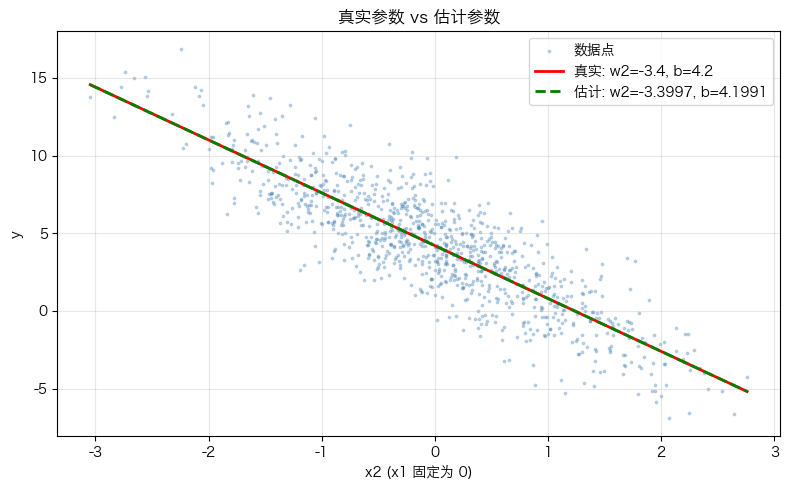

In [12]:
import matplotlib.font_manager as fm

fm.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

# 可视化固定 x1=0，沿 x2 轴展示（X~N(0,1)，x1 均值为 0）
x2_vals = features[:, 1]
y_vals  = labels.flatten()

x_line = np.linspace(features[:, 1].min(), features[:, 1].max(), 200)

# 真实直线：y = true_w[1]*x2 + true_b（x1=0）
y_true_line = true_w[1] * x_line + true_b

# 估计直线：y = w[1]*x2 + b（x1=0）
y_pred_line = (w[1] * x_line + b).flatten()

plt.figure(figsize=(8, 5))
plt.scatter(x2_vals, y_vals, s=3, alpha=0.3, color='steelblue', label='数据点')
plt.plot(x_line, y_true_line, 'r-',  linewidth=2,
         label=f'真实: w2={true_w[1]:.1f}, b={true_b}')
plt.plot(x_line, y_pred_line, 'g--', linewidth=2,
         label=f'估计: w2={w[1].item():.4f}, b={b.item():.4f}')
plt.xlabel('x2 (x1 固定为 0)')
plt.ylabel('y')
plt.title('真实参数 vs 估计参数')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
